In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
TEST_YEAR = '2014'

train_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\GR_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_WNV_Dataset_GRID_OP_2014.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(52992, 91)


In [2]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [3]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL52,EL524,εδεσσας,2014,1,21.76334,40.79806,0.419119,0.028077,-0.375266,-0.028077,0.415407,0.024159,-0.375917,-0.024159,0.050214,0.058229,0.026335,0.058229,5.727419,9.122258,9.445714,15.065484,17.268667,-1.137742,1.355806,1.090714,3.553226,4.300000,2.294839,5.239032,5.268214,9.309355,10.784333,-6.35,9.11,3.002079,28.288851,29.763981,30.778578,99.018190,13.333333,23.833333,54.166667,863.484835,38.0,-6.0,44.0,4.166667,23.000000,23.000000,2.500000,1332.0,210.0,25.0,47.328320,498.0,166.0,166.0,452.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2
1,1,EL52,EL524,εδεσσας,2014,1,21.76334,40.81603,0.434850,0.023073,-0.417086,-0.023073,0.435708,0.023537,-0.417933,-0.023537,0.036778,0.041983,0.025592,0.041983,6.491290,9.644839,10.555000,16.023548,18.036667,-2.076452,1.202258,1.326429,1.330000,5.474667,2.207419,5.423548,5.940714,8.676774,11.755667,-8.19,11.27,2.958736,29.511601,31.584563,32.539087,98.380803,12.875000,23.916667,54.356061,857.884555,35.0,-9.0,44.0,3.166667,22.166667,22.166667,1.500000,1392.0,256.0,29.0,52.707463,556.0,173.0,173.0,505.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2
2,2,EL52,EL524,εδεσσας,2014,1,21.76334,40.83400,0.352225,-0.077751,-0.461722,0.077751,0.353621,-0.074854,-0.460601,0.074854,0.022683,0.020575,0.033203,0.020575,6.551290,9.875806,9.972857,15.469355,19.748000,-3.117742,0.221613,1.515714,1.266129,2.880000,1.716774,5.048710,5.744286,8.367742,11.314000,-5.75,12.15,2.958736,29.511601,31.584563,32.539087,98.380803,11.708333,22.083333,49.074074,859.296312,34.0,-11.0,45.0,1.166667,20.500000,20.833333,-0.333333,1392.0,256.0,29.0,52.707463,556.0,173.0,192.0,505.0,31,36,30,12,12,3,5,8,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2
3,3,EL52,EL524,εδεσσας,2014,1,21.76334,40.85196,0.231069,0.046914,-0.087845,-0.046914,0.356567,-0.002276,-0.376300,0.002276,0.052437,0.046855,0.130983,0.046855,4.550000,5.948065,5.935714,13.804839,17.968667,-1.759032,0.655161,1.602857,1.833871,2.872667,1.395484,3.301613,3.769286,7.819355,10.420667,-5.47,10.15,2.958736,29.511601,31.584563,32.539087,98.380803,10.583333,20.000000,48.780488,789.082705,31.0,-10.0,41.0,0.333333,18.666667,18.666667,-0.333333,1392.0,256.0,29.0,52.707463,556.0,173.0,173.0,505.0,31,36,30,12,12,3,5,8,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2
4,4,EL52,EL524,εδεσσας,2014,1,21.78676,40.79806,-0.282912,0.660741,0.879714,-0.660741,0.012457,0.383325,0.352560,-0.383325,0.255772,0.239691,0.458782,0.239691,7.190000,7.475806,9.861429,13.462903,16.962000,4.686774,4.145484,3.749286,5.451290,8.540667,5.938387,5.810645,6.

In [4]:
len(data_train.cell_code.unique())

4260

In [5]:
len(data_test.cell_number.unique())

4416

In [6]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
data_train.cases.sum()

1364

In [8]:
# data_test.cases.sum()

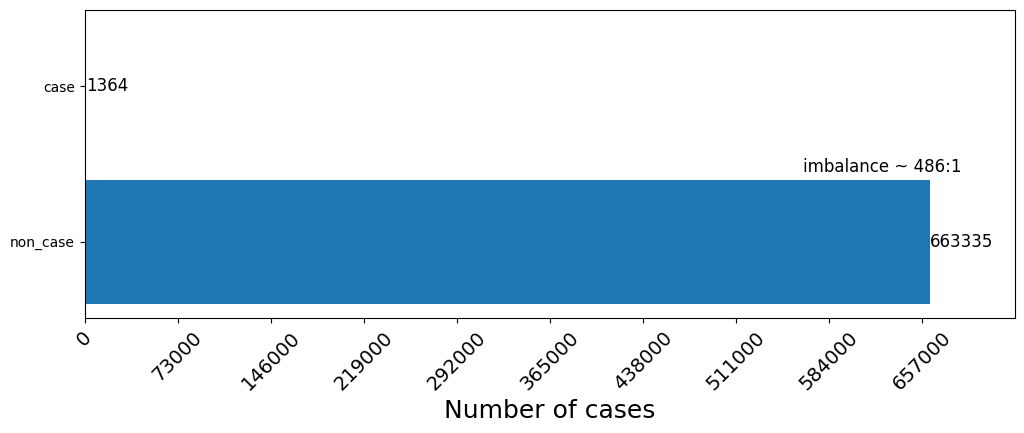

In [9]:
plot_imbalance(data_train, target_column='cases')

In [10]:
# plot_imbalance(data_test, target_column='cases')

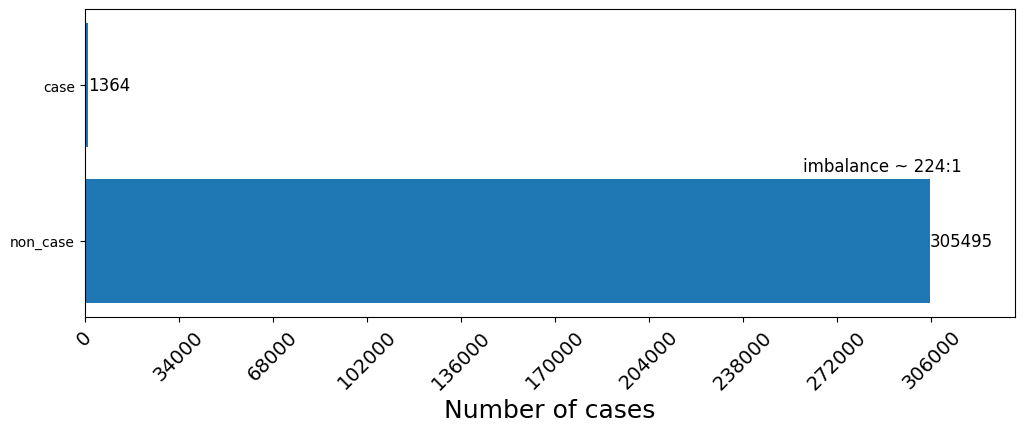

In [11]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [12]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

# plot_imbalance(data_test, target_column='cases')

In [13]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

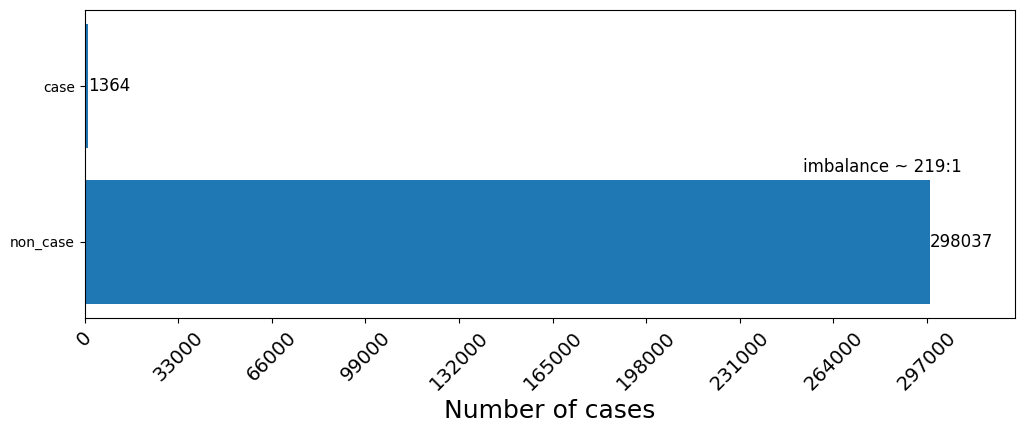

In [14]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [15]:
# hot_cells = dataset[dataset['cases']>0].cell_code.unique().tolist()

# dataset = dataset.query("cell_code in @hot_cells")

# dataset.reset_index(drop=True, inplace=True)

# plot_imbalance(dataset, target_column='cases')

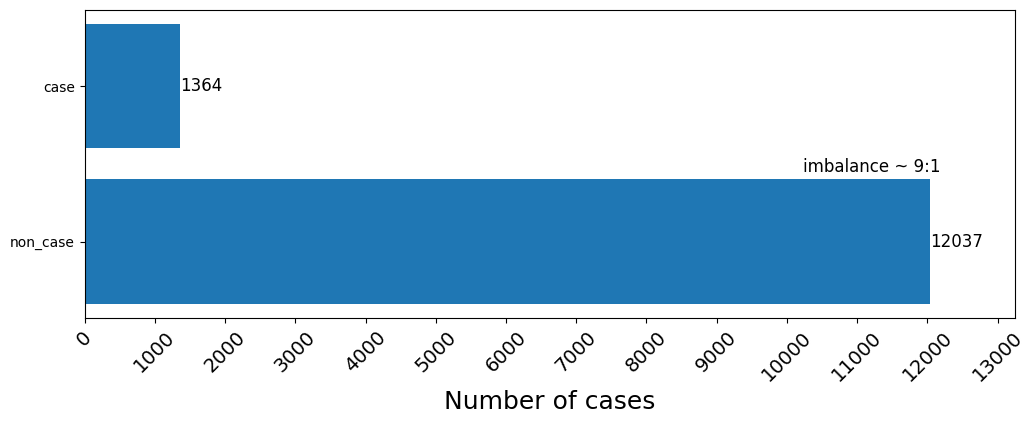

In [16]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [17]:
data_train.shape

(13262, 94)

In [18]:
data_train.cases.sum()

1364

In [19]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1034,262,1296,3.95%
1,2011,977,100,1077,9.77%
2,2012,1025,157,1182,6.53%
3,2013,1037,85,1122,12.20%
4,2014,709,15,724,47.27%
5,2015,1010,0,1010,inf%
6,2016,1057,0,1057,inf%
7,2017,976,42,1018,23.24%
8,2018,1022,296,1318,3.45%
9,2019,1056,218,1274,4.84%


In [20]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [21]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 8.82
Weight: 8.82


In [22]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [23]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL52,EL524,εδεσσας,2014,5,21.76334,40.79806,0.333208,-0.061108,-0.375639,0.061108,0.309387,-0.087841,-0.389210,0.087841,0.026055,0.027747,0.016267,0.027747,17.268667,9.122258,9.445714,15.065484,17.268667,4.300000,1.355806,1.090714,3.553226,4.300000,10.784333,5.239032,5.268214,9.309355,10.784333,-3.37,22.25,7.674675,148.080434,193.124116,230.240264,580.787978,13.333333,23.833333,54.166667,863.484835,38.0,-6.0,44.0,4.166667,23.000000,23.000000,2.500000,1332.0,210.0,25.0,47.328320,498.0,166.0,166.0,452.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2,0.500000,-0.866025
1,1,EL52,EL524,εδεσσας,2014,5,21.76334,40.81603,0.321002,-0.093861,-0.447828,0.093861,0.318250,-0.096028,-0.438302,0.096028,0.007351,0.016843,0.014705,0.016843,18.036667,9.644839,10.555000,16.023548,18.036667,5.474667,1.202258,1.326429,1.330000,5.474667,11.755667,5.423548,5.940714,8.676774,11.755667,1.53,22.25,7.978674,123.414199,170.485148,239.360234,574.752598,12.875000,23.916667,54.356061,857.884555,35.0,-9.0,44.0,3.166667,22.166667,22.166667,1.500000,1392.0,256.0,29.0,52.707463,556.0,173.0,173.0,505.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2,0.500000,-0.866025
2,2,EL52,EL524,εδεσσας,2014,5,21.76334,40.83400,0.297587,-0.051576,-0.390473,0.051576,0.334888,-0.076801,-0.430286,0.076801,0.038284,0.050290,0.041006,0.050290,19.748000,9.875806,9.972857,15.469355,19.748000,2.880000,0.221613,1.515714,1.266129,2.880000,11.314000,5.048710,5.744286,8.367742,11.314000,-0.01,23.97,7.978674,123.414199,170.485148,239.360234,574.752598,11.708333,22.083333,49.074074,859.296312,34.0,-11.0,45.0,1.166667,20.500000,20.833333,-0.333333,1392.0,256.0,29.0,52.707463,556.0,173.0,192.0,505.0,31,36,30,12,12,3,5,8,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2,0.500000,-0.866025
3,3,EL52,EL524,εδεσσας,2014,5,21.76334,40.85196,0.296545,-0.127080,-0.448146,0.127080,0.303822,-0.098355,-0.427280,0.098355,0.021160,0.021143,0.026852,0.021143,17.968667,5.948065,5.935714,13.804839,17.968667,2.872667,0.655161,1.602857,1.833871,2.872667,10.420667,3.301613,3.769286,7.819355,10.420667,-0.45,19.87,7.978674,123.414199,170.485148,239.360234,574.752598,10.583333,20.000000,48.780488,789.082705,31.0,-10.0,41.0,0.333333,18.666667,18.666667,-0.333333,1392.0,256.0,29.0,52.707463,556.0,173.0,173.0,505.0,31,36,30,12,12,3,5,8,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,10756.0,43966.0,14892.0,69614.0,10480.0,43054.0,18045.0,71579.0,1593.84,NaN,NaN,2,3,2,0.500000,-0.866025
4,4,EL52,EL524,εδεσσας,2014,5,21.78676,40.79806,-0.078647,0.277999,0.512661,-0.277999,0.290609,0.103481,-0.163231,-0.103481,0.060059,0.029860,0.087920,0.02

### Results 2014 ###

In [24]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_may['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [25]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jun['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jul['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_aug['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_sep['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_oct['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2964,2964,EL52,EL527,νεας προποντιδας,2014,5,23.33265,40.15126,0.057076
3299,3299,EL52,EL527,πολυγυρου,2014,5,23.44976,40.29500,0.034479
2667,2667,EL52,EL527,πολυγυρου,2014,5,23.21554,40.45670,0.029616
3097,3097,EL52,EL527,κασσανδρας,2014,5,23.37949,40.11533,0.020593
2607,2607,EL52,EL527,πολυγυρου,2014,5,23.19211,40.42076,0.020494


In [31]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2023,2023,EL52,EL522,αμπελοκηπων μενεμενης,2014,6,22.93447,40.65433,0.190897
1579,1579,EL52,EL522,χαλκηδονος,2014,6,22.65339,40.70823,0.125997
1546,1546,EL52,EL522,χαλκηδονος,2014,6,22.62997,40.70823,0.123785
1516,1516,EL52,EL524,πελλας,2014,6,22.60655,40.81603,0.120728
997,997,EL52,EL521,αλεξανδρειας,2014,6,22.39575,40.61840,0.120099


In [32]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2024,2024,EL52,EL522,παυλου μελα,2014,7,22.93447,40.67230,0.941738
2551,2551,EL52,EL527,πολυγυρου,2014,7,23.16869,40.45670,0.933682
2552,2552,EL52,EL527,πολυγυρου,2014,7,23.16869,40.47466,0.924486
1979,1979,EL52,EL522,αμπελοκηπων μενεμενης,2014,7,22.91104,40.65433,0.923421
3604,3604,EL52,EL526,σερρων,2014,7,23.54345,41.08553,0.915874


In [33]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3120,3120,EL52,EL522,βολβης,2014,8,23.37949,40.69026,0.960236
3096,3096,EL52,EL527,κασσανδρας,2014,8,23.37949,40.09736,0.957882
2023,2023,EL52,EL522,αμπελοκηπων μενεμενης,2014,8,22.93447,40.65433,0.956463
2024,2024,EL52,EL522,παυλου μελα,2014,8,22.93447,40.67230,0.952480
555,555,EL52,EL521,βεροιας,2014,8,22.20837,40.52856,0.941065


In [34]:
results_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3097,3097,EL52,EL527,κασσανδρας,2014,9,23.37949,40.11533,0.832756
3136,3136,EL52,EL526,βισαλτιας,2014,9,23.37949,40.97773,0.797991
3539,3539,EL52,EL526,σερρων,2014,9,23.52003,41.10350,0.795449
3205,3205,EL52,EL526,βισαλτιας,2014,9,23.40292,40.97773,0.794734
2964,2964,EL52,EL527,νεας προποντιδας,2014,9,23.33265,40.15126,0.789429


In [35]:
results_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3604,3604,EL52,EL526,σερρων,2014,10,23.54345,41.08553,0.157558
3978,3978,EL52,EL526,βισαλτιας,2014,10,23.68399,40.90586,0.136152
3800,3800,EL52,EL526,εμμανουηλ παππα,2014,10,23.61372,41.04960,0.132476
3670,3670,EL52,EL526,σερρων,2014,10,23.56687,41.08553,0.111889
3281,3281,EL52,EL526,ηρακλειας,2014,10,23.42634,41.13943,0.108684


In [36]:
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"
cm_grid = gpd.read_file(r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [37]:
cm_grid.head()

,cell_numbe,NUTS2_ID,x,y,geometry
0,0,EL52,21.76334,40.79806,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,21.76334,40.81603,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,21.76334,40.83400,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,21.76334,40.85196,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,21.78676,40.79806,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [38]:
greece_nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [39]:
greece_lau1.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [40]:
greece_lakes.head()

,objectid,EU_CD,MS_CD,NAME,ALTNAME1,ALTNAME2,ALTNAME3,BASIN_CD,CHARACTER_,shape_area,shape_len,geometry
0,1,GR001100030020H,001100030020H,????? ???????,KERKINI LAKE,None,None,11,Insufficient Data,46088780.0,70604.0100,"POLYGON ((23.08306 41.19977, 23.08406 41.20032..."
1,2,GR001200030030N,001200030030N,????? ????????,ISMARIDA LAKE,None,None,12,Insufficient Data,1865103.9,5520.0850,"POLYGON ((25.30798 40.99044, 25.30862 40.99215..."
2,3,GR000800030010H,000800030010H,??????? ????? ??????,KARLAS RESERVOIR,None,None,08,Insufficient Data,34925588.0,29704.8950,"POLYGON ((22.78068 39.49602, 22.78083 39.49649..."
3,4,GR000800030020H,000800030020H,??????? ????? ????????,SMOKOVO RESERVOIR,None,None,08,Insufficient Data,9917521.0,57610.2000,"POLYGON ((22.04919 39.10001, 22.05059 39.10001..."
4,5,GR001300030020N,001300030020N,????? ??????,KOURNA LAKE,None,None,13,No Risk,561666.4,2849.8203,"POLYGON ((24.27341 35.33136, 24.27384 35.33312..."


In [41]:
cm_grid = cm_grid.to_crs(epsg=4326)
cm_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
cm_grid = cm_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {cm_grid.crs}')

greece_index CRS: EPSG:4326


In [42]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == 'EL52']
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts2 CRS: EPSG:4326


In [43]:
greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME'], inplace=True)

wrong_list = ['Φλώρινας' ,'Αμυνταίου', 'Εορδαίας', 'Κοζάνης', 'Σερβίων - Βελβεντού', 'Ελασσόνας', 'Τεμπών', 'Κάτω Νευροκοπίου',
 'Προσοτσάνης', 'Δοξάτου', 'Παγγαίου', 'Άθως']

greece_lau1 = greece_lau1[~greece_lau1['NAME'].isin(wrong_list)].copy()
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lau1 CRS: EPSG:4326


In [44]:
greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_lakes CRS: EPSG:4326


In [45]:
cm_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [46]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [47]:
greece_lau1.head()

,NAME,geometry
0,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
1,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
2,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
3,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
4,Αμφίπολης,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."


In [48]:
greece_lakes.head()

,name,area,length,geometry
0,DOIRANI LAKE,38845664.0,23830.293,"POLYGON ((22.74871 41.17307, 22.75127 41.19256..."
1,VEGORITIDA LAKE,53967632.0,44307.140,"POLYGON ((21.78009 40.74340, 21.79369 40.77087..."
2,SFIKIAS RESERVOIR,3668518.8,24065.023,"MULTIPOLYGON (((22.15441 40.35638, 22.15217 40..."
3,KERKINI LAKE,46088780.0,70604.010,"POLYGON ((23.08406 41.20032, 23.08512 41.20179..."
4,PIKROLIMNI RESERVOIR,4270964.0,9538.072,"POLYGON ((22.79801 40.83966, 22.79871 40.84039..."


In [49]:
results_may = pd.merge(results_may, cm_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')

results_jun = pd.merge(results_jun, cm_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')

results_jul = pd.merge(results_jul, cm_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')

results_aug = pd.merge(results_aug, cm_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')

results_sep = pd.merge(results_sep, cm_grid, on='cell_number', how='left')
results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')

results_oct = pd.merge(results_oct, cm_grid, on='cell_number', how='left')
results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')

In [50]:
float_column = 'score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm

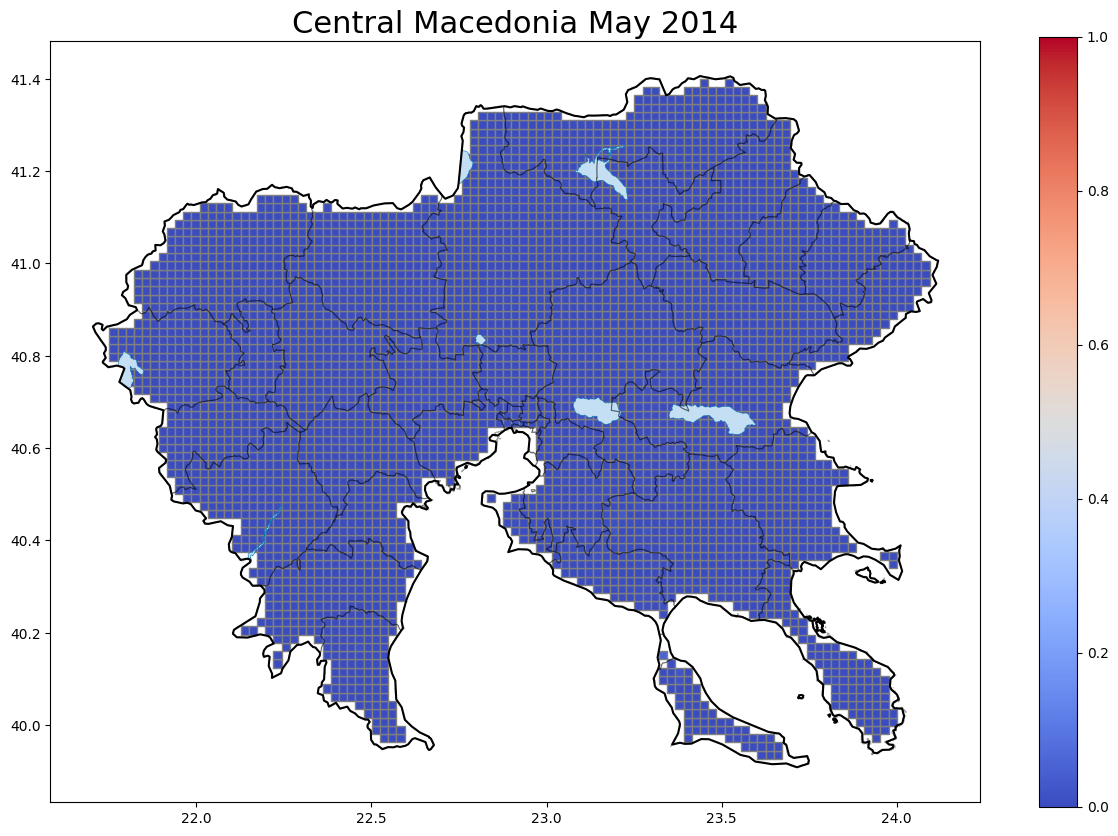

In [51]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia May {TEST_YEAR}', size = 22)
plt.show()

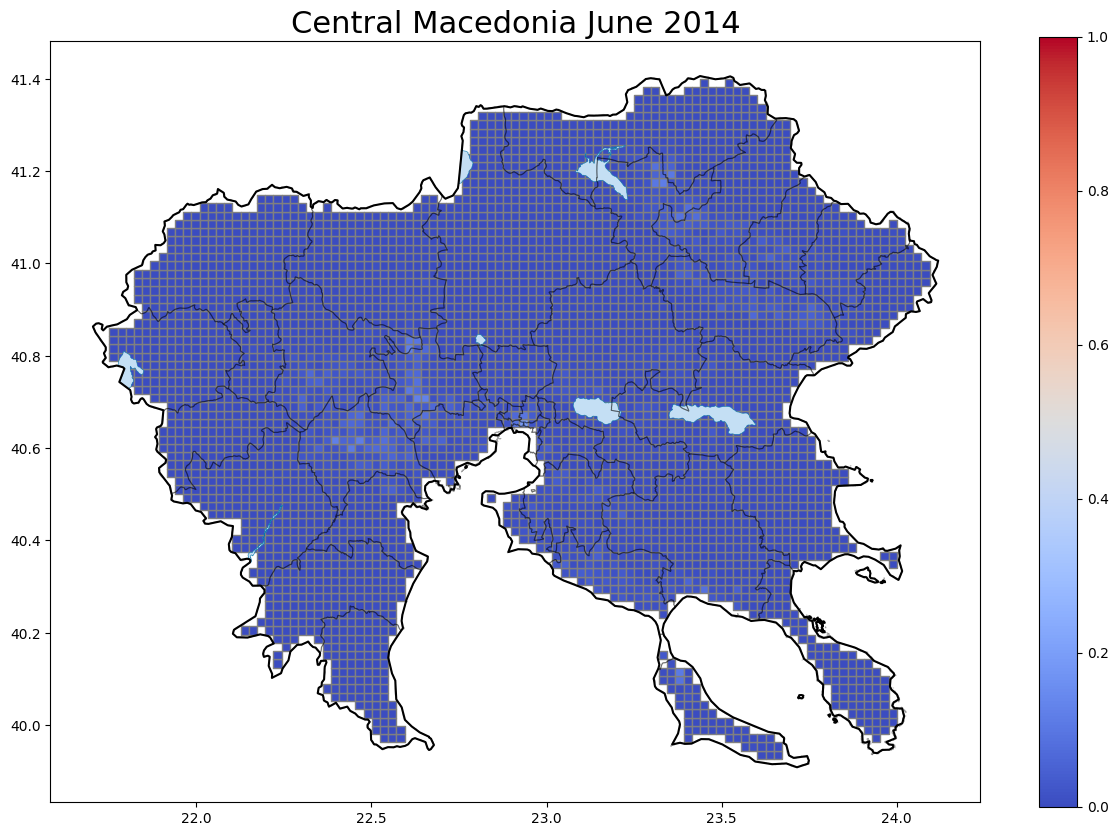

In [52]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia June {TEST_YEAR}', size = 22)
plt.show()

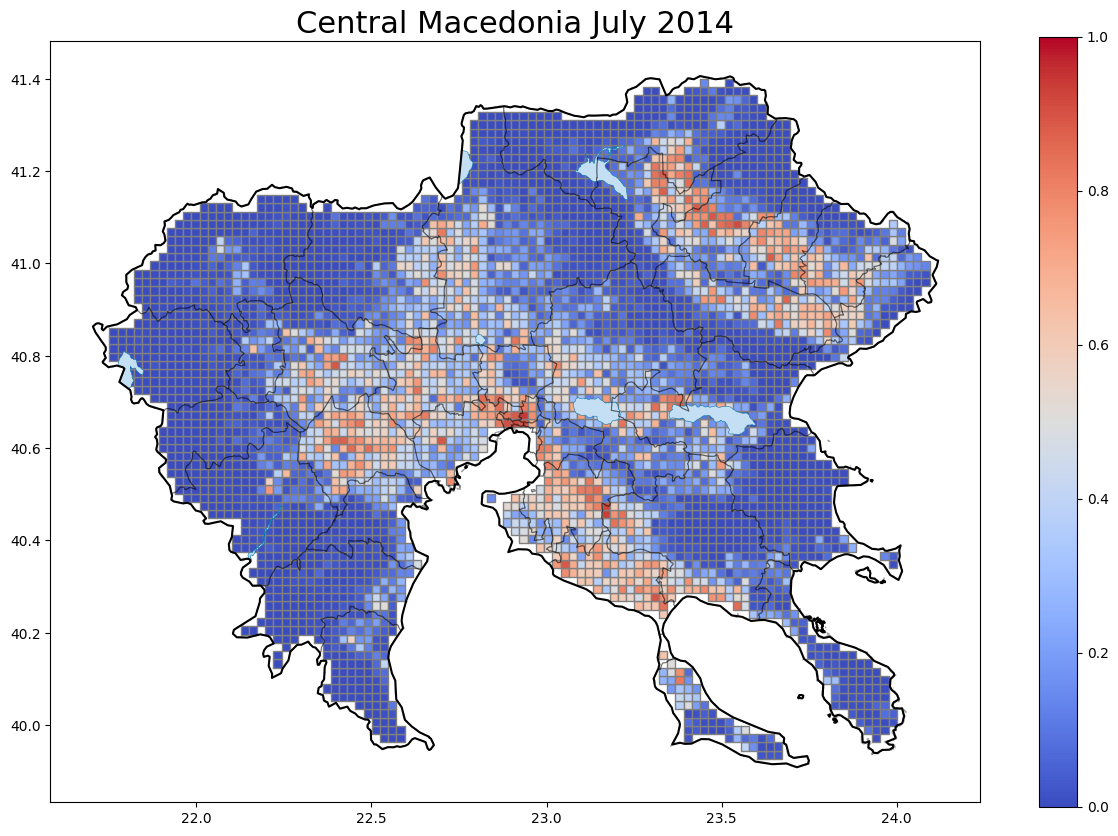

In [53]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia July {TEST_YEAR}', size = 22)
plt.show()

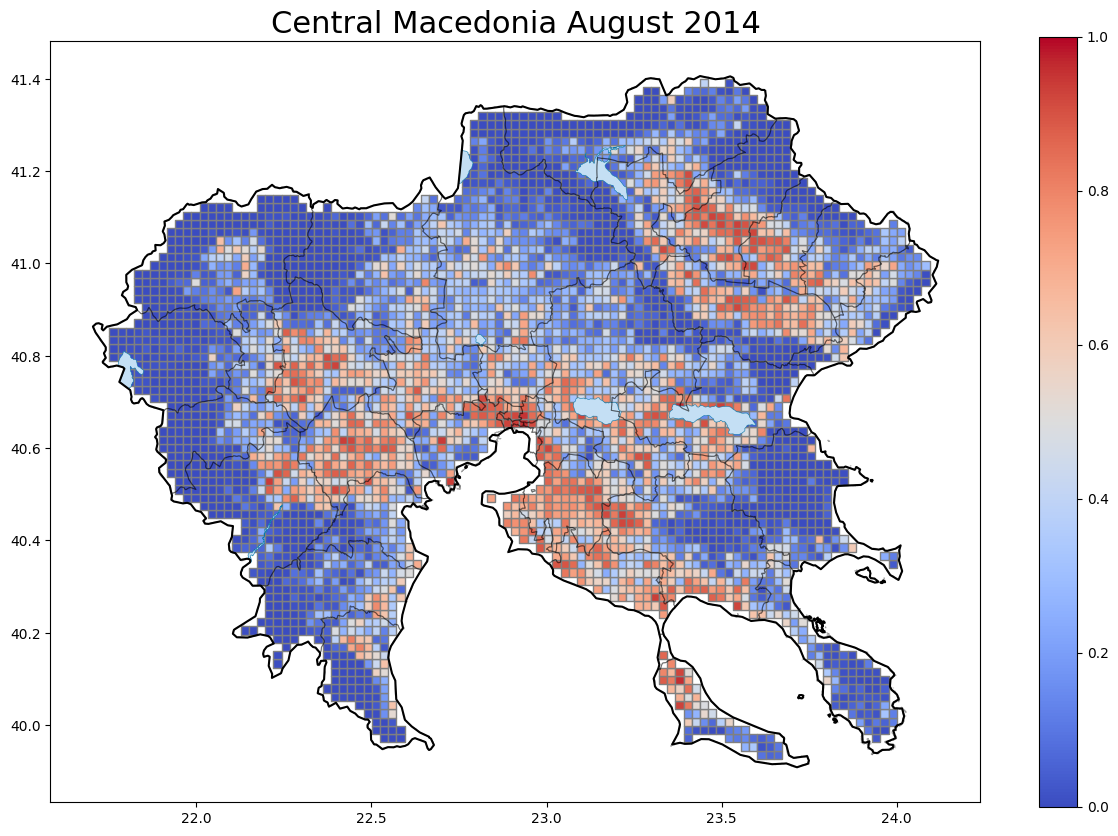

In [54]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia August {TEST_YEAR}', size = 22)
plt.show()

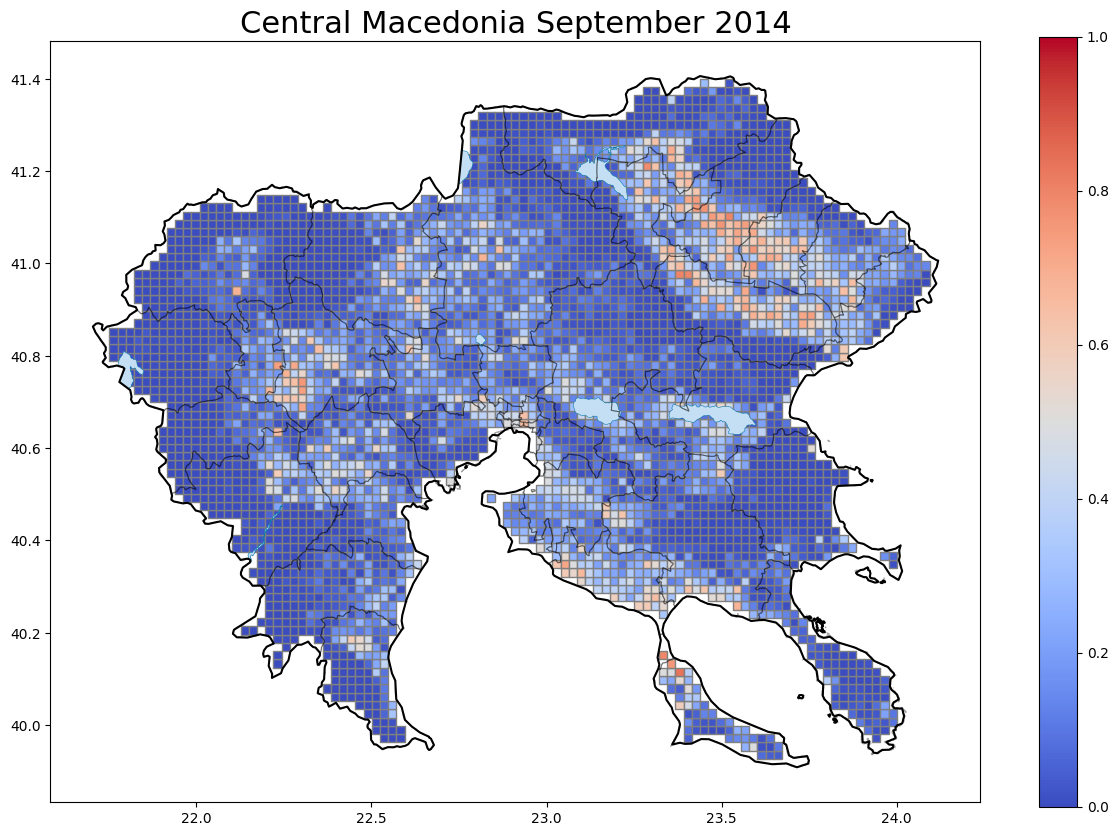

In [55]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia September {TEST_YEAR}', size = 22)
plt.show()

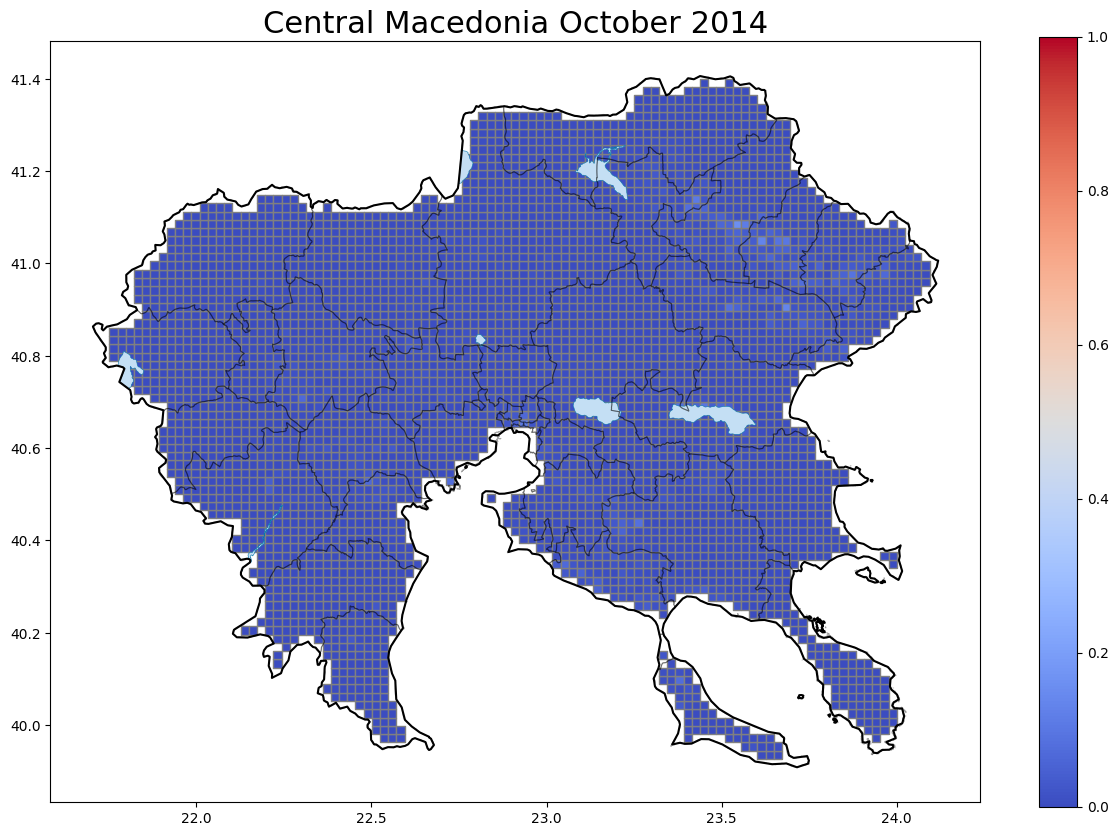

In [56]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth = 0.4)
greece_nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', edgecolor='black', linewidth = 0.8, alpha = 0.35)

plt.title(f'Central Macedonia October {TEST_YEAR}', size = 22)
plt.show()